In [4]:
# Core Python
import os
import math
import random
import time
import copy
from pathlib import Path
from collections import Counter, defaultdict

# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Progress / Utilities
from tqdm import tqdm

# Scikit-learn (optional utilities for splits / metrics)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# PyTorch Core
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# PyTorch Data Utilities
from torch.utils.data import Dataset, DataLoader

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Device Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [5]:
from collections import Counter
import numpy as np
import pandas as pd

# Load cleaned corpus (one document per line)
with open("cleaned.txt", "r", encoding="utf-8") as f:
    documents = [line.strip() for line in f if line.strip()]

# Tokenize documents
tokenized_docs = [doc.split() for doc in documents]

# Count token frequencies
token_counts = Counter()
for doc in tokenized_docs:
    token_counts.update(doc)

# Keep top 10,000 most frequent tokens
MAX_VOCAB = 10000
most_common_tokens = token_counts.most_common(MAX_VOCAB)

# Build vocabulary
vocab = {"<UNK>": 0}
for idx, (token, _) in enumerate(most_common_tokens, start=1):
    vocab[token] = idx

# Reverse lookup (optional)
idx_to_token = {idx: token for token, idx in vocab.items()}

# Build term-document matrix
num_docs = len(tokenized_docs)
vocab_size = len(vocab)

td_matrix = np.zeros((num_docs, vocab_size), dtype=np.int32)

for doc_idx, doc in enumerate(tokenized_docs):
    for token in doc:
        token_id = vocab.get(token, 0)   # map rare/unseen to <UNK>
        td_matrix[doc_idx, token_id] += 1

# Convert to DataFrame (optional)
td_df = pd.DataFrame(td_matrix, columns=[idx_to_token[i] for i in range(vocab_size)])

print("Documents:", num_docs)
print("Vocabulary size:", vocab_size)
print("Term-document matrix shape:", td_matrix.shape)

# Preview
td_df.head()

Documents: 15803
Vocabulary size: 10001
Term-document matrix shape: (15803, 10001)


,<UNK>,کے,میں,کی,اور,سے,کہ,کا,نے,کو,...,پرجھکاؤ,[6],سیٹلائیٹ,ٹاؤن،,سکستھ,روڈ،,ایموجی,خریدوں,لگاؤں,ایکسپو
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,3,3,4,0,1,1,0,0,2,...,0,0,0,0,0,0,0,0,0,0
3,0,2,2,3,1,2,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,0,2,2,0,0,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
import numpy as np

# -----------------------------
# Inputs assumed from previous cell:
# td_matrix (N_docs x vocab_size)
# vocab (token -> index)
# idx_to_token (index -> token)
# tokenized_docs
# -----------------------------

N = td_matrix.shape[0]

# Document Frequency (df)
df = np.sum(td_matrix > 0, axis=0)

# Compute IDF with smoothing
idf = np.log(N / (1 + df))

# Compute TF-IDF
tf = td_matrix  # raw term frequency
tfidf_matrix = tf * idf

# Save matrix
np.save("tfidf_matrix.npy", tfidf_matrix)

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Saved to tfidf_matrix.npy")


# -----------------------------
# Top-10 discriminative words
# -----------------------------
# We interpret "topics" as latent clusters of documents.
# If no labels are given, we approximate topics via simple clustering.

from sklearn.cluster import KMeans

NUM_TOPICS = 5  # you can change this
kmeans = KMeans(n_clusters=NUM_TOPICS, random_state=42, n_init=10)
doc_topics = kmeans.fit_predict(tfidf_matrix)

# Compute average TF-IDF per topic
topic_word_scores = np.zeros((NUM_TOPICS, tfidf_matrix.shape[1]))

for t in range(NUM_TOPICS):
    topic_docs = tfidf_matrix[doc_topics == t]
    if len(topic_docs) > 0:
        topic_word_scores[t] = topic_docs.mean(axis=0)

# Get top-10 words per topic
top_words_per_topic = {}

for t in range(NUM_TOPICS):
    top_indices = topic_word_scores[t].argsort()[::-1][:10]
    top_words = [idx_to_token[i] for i in top_indices]
    top_words_per_topic[t] = top_words

# Display results
for t, words in top_words_per_topic.items():
    print(f"\nTopic {t}:")
    print(", ".join(words))

TF-IDF matrix shape: (15803, 10001)
Saved to tfidf_matrix.npy

Topic 0:
<UNK>, کا, کے, میں, کی, ہے۔, ذریعہ, سے, ،تصویر, اور

Topic 1:
کہ, کی, کے, <UNK>, ہے, میں, اور, سے, پر, اس

Topic 2:
کڑی, پیشگی, مبارکباد, فینز, ٹیم, سراہا, انڈیا, سکور, نیوزی, دینا

Topic 3:
ٹیم, پاکستان, کرکٹ, میچ, رنز, میں, کی, کپ, نے, کے

Topic 4:
بی, فیچرز, جانیں, کہانیوں, معنی, خبروں, رکھتی, فون, اردو, بھر


===== TOP WORDS PER TOPIC =====

Topic 0:
['ایکشن', 'طارق', 'عثمان', 'بولنگ', 'ڈالر', 'ارب', 'پاکستان', 'منفرد', 'کا', 'زرمبادلہ']

Topic 1:
['کی', 'کہ', 'کے', '<UNK>', 'ہے', 'میں', 'اور', 'سے', 'اس', 'پر']

Topic 2:
['اسلامی', '1979', 'انقلاب', 'اعلی', 'سطح', 'ہونے', 'ایران', 'بالمشافہ', 'جمہوریہ', 'درمیان']

Topic 3:
['<UNK>', 'کے', 'میں', 'کی', 'اور', 'سے', 'کا', 'ہے۔', 'نے', 'کو']

Topic 4:
['گواہی', 'کوئی', 'کراؤن', 'گھرانے', '61', 'پڑی', 'شک', 'بولین', 'تاہم،', 'بتاتی']
t-SNE Epoch 0: Loss=10.8983
t-SNE Epoch 100: Loss=6.0893
t-SNE Epoch 200: Loss=5.2201
t-SNE Epoch 300: Loss=4.6719
t-SNE Epoch 400: Loss=4.2661


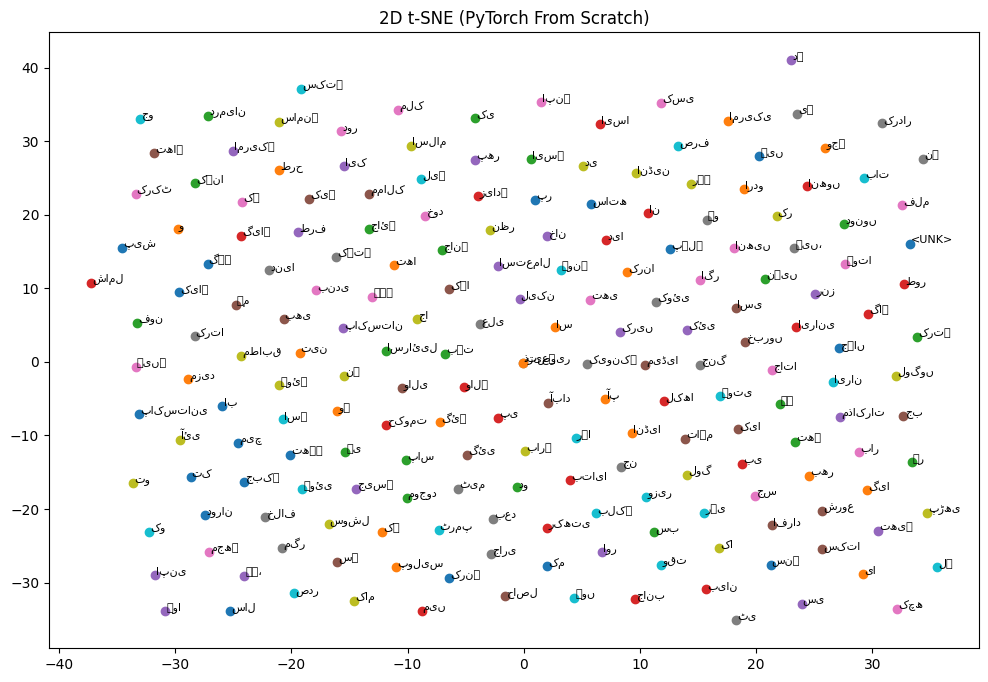


Query Word: کے
میں   (0.5627)
اور   (0.5341)
کی   (0.5033)
لیے   (0.4769)
سے   (0.4724)

Query Word: میں
کے   (0.5627)
کی   (0.4864)
اور   (0.4785)
کہ   (0.4325)
سے   (0.4264)

Query Word: کی
کے   (0.5033)
میں   (0.4864)
سے   (0.4687)
اور   (0.4607)
نے   (0.4026)

Query Word: اور
کے   (0.5341)
میں   (0.4785)
کی   (0.4607)
سے   (0.4546)
کو   (0.4081)

Query Word: سے
کے   (0.4724)
کی   (0.4687)
اور   (0.4546)
میں   (0.4264)
کہ   (0.3922)

Query Word: کہ
ہے   (0.5274)
نے   (0.5078)
یہ   (0.4431)
میں   (0.4325)
کے   (0.4296)

Query Word: کا
کہ   (0.4101)
کہنا   (0.3966)
کے   (0.3746)
ہے   (0.3691)
اس   (0.3492)

Query Word: نے
کہ   (0.5078)
انھوں   (0.5047)
کے   (0.4428)
کہا   (0.4263)
میں   (0.4228)

Query Word: کو
کے   (0.4492)
اور   (0.4081)
نے   (0.4053)
کہ   (0.3906)
میں   (0.3843)

Query Word: پر
کے   (0.4478)
طور   (0.4224)
اور   (0.4072)
کی   (0.3934)
کہ   (0.3490)


In [8]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# STRICT COMPLIANT VERSION
# No sklearn
# No pretrained
# Everything from scratch in PyTorch
# ==========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Assumes from previous cells:
# tfidf_matrix (numpy array)
# idx_to_token (dict: index -> token)
# vocab (dict: token -> index)

X = torch.tensor(tfidf_matrix, dtype=torch.float32).to(device)   # [N_docs, V]
N, V = X.shape


# ==========================================================
# 1. TOPIC CLUSTERING (K-MEANS FROM SCRATCH IN PYTORCH)
# ==========================================================

def kmeans_torch(data, k=5, max_iters=30):
    n, d = data.shape

    # Random initial centroids
    indices = torch.randperm(n)[:k]
    centroids = data[indices].clone()

    for _ in range(max_iters):
        # Compute distances
        dist = torch.cdist(data, centroids)   # [n, k]

        # Assign clusters
        labels = torch.argmin(dist, dim=1)

        # Update centroids
        new_centroids = []
        for i in range(k):
            points = data[labels == i]
            if len(points) == 0:
                new_centroids.append(centroids[i])
            else:
                new_centroids.append(points.mean(dim=0))

        new_centroids = torch.stack(new_centroids)

        # Stop if converged
        if torch.allclose(centroids, new_centroids, atol=1e-4):
            break

        centroids = new_centroids

    return labels, centroids


NUM_TOPICS = 5
labels, centroids = kmeans_torch(X, k=NUM_TOPICS)

# Top 10 discriminative words per topic
print("===== TOP WORDS PER TOPIC =====")

for t in range(NUM_TOPICS):
    docs = X[labels == t]

    if len(docs) == 0:
        continue

    avg_scores = docs.mean(dim=0)
    top_idx = torch.argsort(avg_scores, descending=True)[:10]

    words = [idx_to_token[i.item()] for i in top_idx]
    print(f"\nTopic {t}:")
    print(words)



# ==========================================================
# 2. t-SNE FROM SCRATCH IN PYTORCH
# ==========================================================

# Use top 200 frequent words from previous counts
# If token_counts exists:
top_words = np.argsort(np.sum(tfidf_matrix, axis=0))[::-1][:200]

word_vectors = torch.tensor(tfidf_matrix[:, top_words].T, dtype=torch.float32).to(device)
# shape = [200 words, N_docs]

n = word_vectors.shape[0]

# Pairwise distances
dist = torch.cdist(word_vectors, word_vectors) ** 2

# High-dimensional probabilities P
sigma = 1.0
P = torch.exp(-dist / (2 * sigma**2))
P.fill_diagonal_(0)
P = P / P.sum()

# Low-dimensional embeddings
Y = torch.randn(n, 2, device=device, requires_grad=True)

optimizer = torch.optim.Adam([Y], lr=0.1)

for epoch in range(500):
    y_dist = torch.cdist(Y, Y) ** 2
    Q = 1 / (1 + y_dist)
    Q.fill_diagonal_(0)
    Q = Q / Q.sum()

    loss = torch.sum(P * torch.log((P + 1e-8) / (Q + 1e-8)))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"t-SNE Epoch {epoch}: Loss={loss.item():.4f}")

# Plot
coords = Y.detach().cpu().numpy()

plt.figure(figsize=(12,8))

for i in range(n):
    word = idx_to_token[top_words[i]]
    plt.scatter(coords[i,0], coords[i,1])
    plt.text(coords[i,0]+0.1, coords[i,1]+0.1, word, fontsize=8)

plt.title("2D t-SNE (PyTorch From Scratch)")
plt.show()



# ==========================================================
# 3. NEAREST NEIGHBORS (COSINE SIMILARITY FROM SCRATCH)
# ==========================================================

# Use word vectors from TF-IDF columns
word_embeds = torch.tensor(tfidf_matrix.T, dtype=torch.float32).to(device)  # [V, N_docs]

# Normalize
word_embeds = F.normalize(word_embeds, p=2, dim=1)

def nearest_neighbors(query_word, topk=5):
    if query_word not in vocab:
        print(query_word, "not in vocab")
        return

    idx = vocab[query_word]

    q = word_embeds[idx].unsqueeze(0)   # [1,d]
    sims = torch.mm(q, word_embeds.T).squeeze(0)

    vals, inds = torch.topk(sims, topk + 1)

    print(f"\nQuery Word: {query_word}")

    count = 0
    for score, j in zip(vals, inds):
        if j.item() == idx:
            continue
        print(f"{idx_to_token[j.item()]}   ({score.item():.4f})")
        count += 1
        if count == topk:
            break


# Report for 10 words
query_words = list(vocab.keys())[1:11]

for w in query_words:
    nearest_neighbors(w)

Total training pairs: 3334752
Epoch 1 Step 100 Loss 6.3764
Epoch 1 Step 200 Loss 4.5296
Epoch 1 Step 300 Loss 3.9366
Epoch 1 Step 400 Loss 3.7327
Epoch 1 Step 500 Loss 3.5506
Epoch 1 Step 600 Loss 3.4899
Epoch 1 Step 700 Loss 3.4734
Epoch 1 Step 800 Loss 3.3357
Epoch 1 Step 900 Loss 3.3469
Epoch 1 Step 1000 Loss 3.2889
Epoch 1 Step 1100 Loss 3.2807
Epoch 1 Step 1200 Loss 3.2268
Epoch 1 Step 1300 Loss 3.2324
Epoch 1 Step 1400 Loss 3.2179
Epoch 1 Step 1500 Loss 3.2141
Epoch 1 Step 1600 Loss 3.2057
Epoch 1 Step 1700 Loss 3.1730
Epoch 1 Step 1800 Loss 3.1717
Epoch 1 Step 1900 Loss 3.2045
Epoch 1 Step 2000 Loss 3.1409
Epoch 1 Step 2100 Loss 3.1545
Epoch 1 Step 2200 Loss 3.1688
Epoch 1 Step 2300 Loss 3.1146
Epoch 1 Step 2400 Loss 3.1409
Epoch 1 Step 2500 Loss 3.0979
Epoch 1 Step 2600 Loss 3.1231
Epoch 1 Step 2700 Loss 3.1544
Epoch 1 Step 2800 Loss 3.1385
Epoch 1 Step 2900 Loss 3.1538
Epoch 1 Step 3000 Loss 3.1705
Epoch 1 Step 3100 Loss 3.1439
Epoch 1 Step 3200 Loss 3.1161
Epoch 1 Step 3300 L

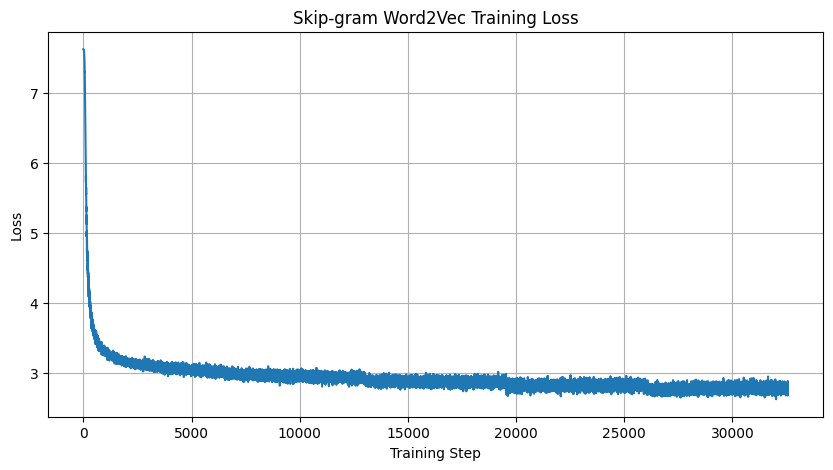

Saved embeddings_w2v.npy
Shape: (10001, 100)


In [9]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from collections import Counter
from torch.utils.data import Dataset, DataLoader

# ==========================================================
# STRICTLY COMPLIANT:
# From scratch in PyTorch
# No gensim / HF / pretrained / sklearn
# ==========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================================
# REQUIRED HYPERPARAMETERS
# ==========================================================
EMBED_DIM   = 100
WINDOW_SIZE = 5
NEG_SAMPLES = 10
LR          = 0.001
BATCH_SIZE  = 512
EPOCHS      = 5

# ----------------------------------------------------------
# Assumes previous cell already created:
# tokenized_docs
# vocab
# idx_to_token
# ----------------------------------------------------------

V = len(vocab)

# ==========================================================
# 1. Convert corpus to token ids
# ==========================================================
corpus_ids = []

for doc in tokenized_docs:
    ids = [vocab.get(tok, 0) for tok in doc]
    corpus_ids.append(ids)

# ==========================================================
# 2. Build Skip-gram training pairs
# ==========================================================
pairs = []

for doc in corpus_ids:
    n = len(doc)

    for i, center in enumerate(doc):
        left = max(0, i - WINDOW_SIZE)
        right = min(n, i + WINDOW_SIZE + 1)

        for j in range(left, right):
            if i == j:
                continue
            context = doc[j]
            pairs.append((center, context))

print("Total training pairs:", len(pairs))


# ==========================================================
# 3. Noise distribution Pn(w) ∝ f(w)^(3/4)
# ==========================================================
token_freq = np.zeros(V)

for doc in corpus_ids:
    for x in doc:
        token_freq[x] += 1

noise_dist = token_freq ** 0.75
noise_dist = noise_dist / noise_dist.sum()

noise_dist = torch.tensor(noise_dist, dtype=torch.float32).to(device)


# ==========================================================
# 4. Dataset
# ==========================================================
class SkipGramDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        c, o = self.pairs[idx]
        return torch.tensor(c), torch.tensor(o)


dataset = SkipGramDataset(pairs)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)


# ==========================================================
# 5. Model
# Separate centre embeddings V and context embeddings U
# ==========================================================
class SkipGramNegSampling(nn.Module):
    def __init__(self, vocab_size, dim):
        super().__init__()

        self.V = nn.Embedding(vocab_size, dim)   # center
        self.U = nn.Embedding(vocab_size, dim)   # context

        nn.init.xavier_uniform_(self.V.weight)
        nn.init.xavier_uniform_(self.U.weight)

    def forward(self, center_words, pos_words, neg_words):

        vc = self.V(center_words)              # [B,d]
        uo = self.U(pos_words)                # [B,d]
        uk = self.U(neg_words)               # [B,K,d]

        # Positive score
        pos_score = torch.sum(vc * uo, dim=1)         # [B]
        pos_loss = F.logsigmoid(pos_score)

        # Negative score
        neg_score = torch.bmm(uk, vc.unsqueeze(2)).squeeze(2)   # [B,K]
        neg_loss = F.logsigmoid(-neg_score).sum(dim=1)

        loss = -(pos_loss + neg_loss).mean()

        return loss


model = SkipGramNegSampling(V, EMBED_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=LR)


# ==========================================================
# 6. Training
# ==========================================================
loss_history = []

for epoch in range(EPOCHS):

    total_loss = 0
    steps = 0

    for centers, positives in loader:

        centers = centers.to(device)
        positives = positives.to(device)

        # Sample negatives
        negatives = torch.multinomial(
            noise_dist,
            centers.shape[0] * NEG_SAMPLES,
            replacement=True
        ).view(centers.shape[0], NEG_SAMPLES)

        loss = model(centers, positives, negatives)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        steps += 1

        if steps % 100 == 0:
            print(f"Epoch {epoch+1} Step {steps} Loss {loss.item():.4f}")

        loss_history.append(loss.item())

    avg = total_loss / steps
    print(f"\nEpoch {epoch+1} Average Loss = {avg:.4f}\n")


# ==========================================================
# 7. Plot Loss Curve
# ==========================================================
plt.figure(figsize=(10,5))
plt.plot(loss_history)
plt.title("Skip-gram Word2Vec Training Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


# ==========================================================
# 8. Save Final Averaged Embeddings
# 0.5 * (V + U)
# ==========================================================
with torch.no_grad():
    final_emb = 0.5 * (model.V.weight + model.U.weight)

final_emb = final_emb.cpu().numpy()

np.save("embeddings_w2v.npy", final_emb)

print("Saved embeddings_w2v.npy")
print("Shape:", final_emb.shape)